In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd
import random
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('input2lstm.csv', index_col=0, low_memory=False)

In [3]:
df.head()

,Close,High,Low,Open,Volume,date,weekday,month,oc,hl,...,GK_Vol_10,GK_Vol_20,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT
0,5993.250000,6006.049805,5982.000000,5982.600098,0,02-01-2013,2,1,0.178015,0.402036,...,NaN,NaN,0,-0.064441,0.0,0.0,NaN,NaN,NaN,NaN
1,6009.500000,6017.000000,5986.549805,6015.799805,0,03-01-2013,3,1,-0.104721,0.508643,...,NaN,NaN,0,0.507392,0.0,0.0,NaN,0.0,NaN,0.0
2,6016.149902,6020.750000,5981.549805,6011.950195,0,04-01-2013,4,1,0.069856,0.655352,...,NaN,NaN,0,0.765302,0.0,0.0,NaN,0.0,NaN,0.0
3,5988.399902,6042.149902,5977.149902,6042.149902,0,07-01-2013,0,1,-0.889584,1.087475,...,NaN,NaN,0,-0.653846,0.0,0.0,NaN,0.0,NaN,0.0
4,6001.700195,6007.049805,5964.399902,5983.450195,0,08-01-2013,1,1,0.305008,0.715075,...,NaN,NaN,0,0.749138,0.0,0.0,NaN,0.0,NaN,0.0


In [4]:
df['Target']=np.where(df['oc'].values<-0.15,0,np.where(df['oc'].values<0.15,1,2))
#df['Target']=df['Target'].shift(-1)
# Fill NaN with a placeholder (e.g., -1) before converting to integer
df['Target'] = df['Target'].fillna(-1).astype(int)

In [5]:
print(df['Target'].dtype)  # Should output 'int32' or 'int64'

int32


In [6]:
 df["cnnstate"] = None

In [7]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'date', 'weekday', 'month',
       'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100', 'EMA_5',
       'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5', 'ROC_10', 'ROC_20',
       'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST', 'KST_Signal', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'BB_PercentB', 'HL_Range', 'HL_EMA', 'CVI',
       'STDDEV_10', 'STDDEV_20', 'Log_Returns', 'HV_10', 'HV_20', 'GK_Vol_10',
       'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD', 'CMF_20', 'FI_13', 'VROC_10',
       'PVT', 'Target', 'cnnstate'],
      dtype='object')

In [8]:
df.tail(2)

,Close,High,Low,Open,Volume,date,weekday,month,oc,hl,...,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT,Target,cnnstate
2943,23813.40039,23938.84961,23800.59961,23801.40039,176800,27-12-2024,4,12,0.050417,0.580868,...,72722400,-0.814817,-144059.6325,39740968.86,-0.030988,11173966.86,-33.558812,333137.2665,1,None
2944,23644.90039,23915.34961,23599.30078,23796.90039,364900,30-12-2024,0,12,-0.638739,1.339230,...,72357500,-0.711439,-259604.2602,39481364.60,-0.109986,-61485650.00,17.671719,330555.2896,0,None


In [9]:
# Drop the last row (as it has no next-day price)
#df = df[:-1]

In [10]:
df = df[100:].reset_index(drop=False)  # Drop first 55 rows and reset index

In [11]:
df.head()

,index,Close,High,Low,Open,Volume,date,weekday,month,oc,...,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT,Target,cnnstate
0,100,6104.299805,6125.049805,6069.799805,6120.450195,120200,29-05-2013,2,5,-0.263876,...,-94800,0.248869,29914.02715,-330473.0473,0.097321,-8.354134e+05,-21.897336,-3061.705179,0,None
1,101,6124.049805,6133.750000,6072.149902,6072.149902,194100,30-05-2013,3,5,0.854720,...,99300,0.685059,132969.97230,-197503.0750,0.107417,3.833475e+06,22.383354,-2433.709319,2,None
2,102,5985.950195,6106.250000,5975.549805,6098.700195,175300,31-05-2013,4,5,-1.848755,...,-76000,-0.840851,-147401.21430,-344904.2893,0.084902,-2.420886e+07,19.008826,-6386.789782,0,None
3,103,5939.299805,6011.000000,5916.350098,5997.350098,112100,03-06-2013,0,6,-0.967932,...,-188100,-0.515061,-57738.35566,-402642.6450,0.033256,-5.229509e+06,-8.340147,-7260.420291,0,None
4,104,5919.450195,5981.600098,5910.250000,5941.100098,114500,04-06-2013,1,6,-0.364409,...,-302600,-0.742111,-84971.73425,-487614.3792,-0.036799,-2.272780e+06,-12.327718,-7643.088353,0,None


In [12]:
df.columns

Index(['index', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'weekday',
       'month', 'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100',
       'EMA_5', 'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5',
       'ROC_10', 'ROC_20', 'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST',
       'KST_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_PercentB',
       'HL_Range', 'HL_EMA', 'CVI', 'STDDEV_10', 'STDDEV_20', 'Log_Returns',
       'HV_10', 'HV_20', 'GK_Vol_10', 'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD',
       'CMF_20', 'FI_13', 'VROC_10', 'PVT', 'Target', 'cnnstate'],
      dtype='object')

In [13]:
# Select features (5 indicators)
features = ['weekday',
       'month', 'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100',
       'EMA_5', 'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5',
       'ROC_10', 'ROC_20', 'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST',
       'KST_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_PercentB',
       'HL_Range', 'HL_EMA', 'CVI', 'STDDEV_10', 'STDDEV_20', 'Log_Returns',
       'HV_10', 'HV_20', 'GK_Vol_10', 'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD',
       'CMF_20', 'FI_13', 'VROC_10', 'PVT']
target = 'Target'

In [14]:
df['Target'].shape

(2845,)

In [15]:
len(features)

52

In [16]:
# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [17]:
# Convert data into sequences for CNN
sequence_length = 60  # Use past 20 days to predict next day

def create_sequences(data, features, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[features].iloc[i:i+seq_length].values)  # Shape (20, 16)
        y.append(data[target].iloc[i+seq_length])  # Target label for the next day
    X = np.array(X)
    y = np.array(y)
    
    # Reshape X for CNN (add channel dimension)
    X = np.expand_dims(X, axis=-1)  # Shape (num_samples, 20, 16, 1)
    
    return X, y


In [18]:
X, y = create_sequences(df, features, target, sequence_length)

In [19]:
df.shape

(2845, 61)

In [20]:
X.shape

(2785, 60, 52, 1)

In [21]:
y.shape

(2785,)

In [22]:
type(y)

numpy.ndarray

In [23]:
type(X)

numpy.ndarray

In [24]:
X[0].shape

(60, 52, 1)

In [25]:
X[0][0].shape

(52, 1)

In [26]:
X[0][0]

array([[5.00000000e-01],
       [3.63636364e-01],
       [4.06469351e-01],
       [3.58658818e-02],
       [6.50740868e-03],
       [8.98936191e-01],
       [3.67667602e-01],
       [3.44342599e-02],
       [8.10438277e-03],
       [5.15538582e-03],
       [3.49893994e-02],
       [3.20134254e-02],
       [2.67464144e-02],
       [7.33865565e-01],
       [5.48012997e-01],
       [7.31383829e-01],
       [2.75844864e-02],
       [1.85907297e-02],
       [5.66118859e-01],
       [6.23919820e-01],
       [4.05432039e-01],
       [6.45363710e-01],
       [6.32113132e-01],
       [6.97106834e-01],
       [4.92344674e-01],
       [6.76355016e-01],
       [6.65924895e-01],
       [4.59205183e-01],
       [8.89411927e-01],
       [9.08569969e-01],
       [2.37844204e-02],
       [2.94702722e-02],
       [4.04186179e-02],
       [6.19659671e-01],
       [1.62024417e-02],
       [6.17471449e-02],
       [1.46325300e-01],
       [5.45203332e-02],
       [3.45400902e-02],
       [6.18271697e-01],


In [27]:
# Define the split index (80% train, 20% test)
split_index = int(0.8 * len(X))

# Train and test split
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Print dataset shapes
print("X_train shape:", X_train.shape)  # (train_samples, 20, 16, 1)
print("y_train shape:", y_train.shape)  # (train_samples,)
print("X_test shape:", X_test.shape)    # (test_samples, 20, 16, 1)
print("y_test shape:", y_test.shape)    # (test_samples,)

X_train shape: (2228, 60, 52, 1)
y_train shape: (2228,)
X_test shape: (557, 60, 52, 1)
y_test shape: (557,)


In [28]:
# Print dataset shape
print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (2228, 60, 52, 1), Labels shape: (2228,)
Testing data shape: (557, 60, 52, 1), Labels shape: (557,)


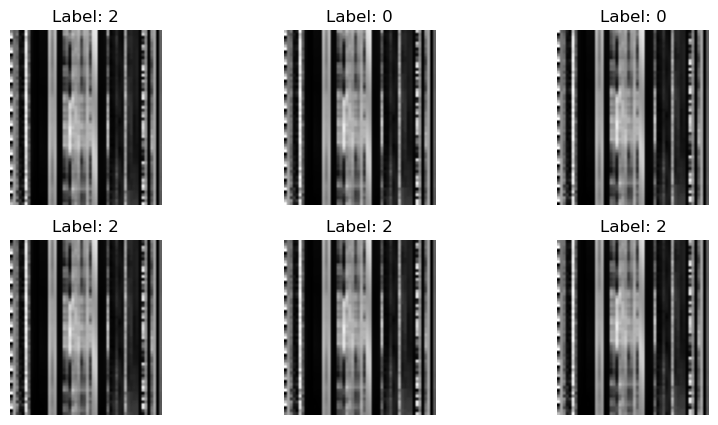

In [29]:
# Display some images
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [30]:
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(60, 52, 1)),  # Explicit Input layer
    layers.Conv2D(32, (3, 3),strides=(1,1), activation='relu'), 
    #layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')  # Output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 58, 50, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 56, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 54, 46, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 27, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 25, 21, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 8, 64)           │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         327,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 457,539 (1.75 MB)

 Trainable params: 457,539 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.4085 - loss: 1.0440 - val_accuracy: 0.3932 - val_loss: 1.0840
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.4203 - loss: 1.0370 - val_accuracy: 0.3932 - val_loss: 1.1003
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.4047 - loss: 1.0353 - val_accuracy: 0.3932 - val_loss: 1.0991
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.4400 - loss: 1.0202 - val_accuracy: 0.3932 - val_loss: 1.0863
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.3931 - loss: 1.0396 - val_accuracy: 0.3932 - val_loss: 1.1077
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.4643 - loss: 1.0283 - val_accuracy: 0.3932 - val_loss: 1.0939
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.4375 - loss: 1.0314 - val_accuracy: 0.3932 - val_loss: 1.0972
Epoch 8/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.4510 - loss: 1.0236 - val_acc

In [ ]:
# Make a prediction
predicted = model.predict(X)
print(predicted)
#print("Predicted Trend:", "UP" if predicted[0] > 0.5 else "DOWN")

In [ ]:
# Convert probabilities to class labels
predicted_classes = np.argmax(predicted, axis=1)  # Get the index of the max value per row

In [ ]:
predicted_classes.shape

In [ ]:
# Get unique elements and their frequencies
unique_elements, counts = np.unique(predicted_classes, return_counts=True)

# Display results
for element, count in zip(unique_elements, counts):
    print(f"Element: {element}, Frequency: {count}")

In [ ]:
df.shape

In [ ]:
df.iloc[60-1:len(df)-1, df.columns.get_loc("cnnstate")] = predicted_classes

In [ ]:
# Compute percentage change in tomorrow's Open price relative to today's Close
df["p_co"] = ((df["Open"].shift(-1)-df["Close"]) / df["Close"]) * 100

In [ ]:
# Apply condition, keeping NaNs unchanged
df['state2d'] = np.where(df['p_co'] > 0, df['cnnstate'] + 3, df['cnnstate'])

In [ ]:
df['state2d'].describe()

In [ ]:
# Plot histogram for categorical data
df['state2d'].value_counts().plot(kind='bar', figsize=(10, 5), color='skyblue', edgecolor='black')

plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Histogram of States')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#df.index = pd.to_datetime(df.index)
df = df.reset_index(drop=True)
df.to_csv('tempcnn.csv', index=True) 